Roof Segmentation by Raffi Satya Nugraha

#Change to Python 3.9

In [ ]:
!sudo apt-get update -y
!sudo apt-get install python3.9 python3.9-distutils -y

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.9 1
!sudo update-alternatives --set python3 /usr/bin/python3.9

!wget https://bootstrap.pypa.io/get-pip.py
!python3.9 get-pip.py

!python3.9 --version

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,123 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,526 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,825 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers

#Install Tensorflow

In [ ]:
!pip install tensorflow==2.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 31.4 MB/s  0:00:10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 93.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 160.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 111.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 111.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 54.8 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 233.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 51.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 107.0 MB/s  0:00:00
  Attempting uninsta

#Preparation

In [ ]:
# import necessary libraries
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Dropout
from tensorflow.keras import Model

from PIL import Image

In [ ]:
# connect google drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
# set the working directory
import os
os.chdir(r'/content/gdrive/MyDrive/dataset/')

## **Data Preprocessing**

In [ ]:
import glob

train_x = sorted(glob.glob('train/*_image.png'))
train_y = sorted(glob.glob('train/*_mask.png'))
test_x = sorted(glob.glob('test/*_image.png'))
test_y = sorted(glob.glob('test/*_mask.png'))

print(len(train_x), len(train_y), len(test_x), len(test_y))

def find_unmatched(images, labels):
    img_basenames = [os.path.basename(f).replace('_image.png', '') for f in images]
    lbl_basenames = [os.path.basename(f).replace('_mask.png', '') for f in labels]

    img_only = sorted(set(img_basenames) - set(lbl_basenames))
    lbl_only = sorted(set(lbl_basenames) - set(img_basenames))

    return img_only, lbl_only

train_img_only, train_lbl_only = find_unmatched(train_x, train_y)
test_img_only, test_lbl_only = find_unmatched(test_x, test_y)


950 950 235 235
=== TRAIN ===
Tanpa label: []
Tanpa image: []
=== TEST ===
Tanpa label: []
Tanpa image: []


In [ ]:
import numpy as np
from PIL import Image

n = len(train_x)
train_xx = np.zeros((n, 128, 128, 3), dtype=np.uint8)
train_yy = np.zeros((n, 128, 128, 1), dtype=np.uint8)

for i, (img, mask) in enumerate(zip(train_x, train_y)):
    img = Image.open(img)
    np_img = np.array(img)
    train_xx[i] = np_img

    mask = Image.open(mask)
    np_mask = np.array(mask).reshape(128, 128, 1)
    train_yy[i] = np_mask


In [ ]:
import numpy as np
from PIL import Image

n = len(test_x)
test_xx = np.zeros((n, 128, 128, 3), dtype=np.uint8)
test_yy = np.zeros((n, 128, 128, 1), dtype=np.uint8)

for i, (img, mask) in enumerate(zip(test_x, test_y)):
    img = Image.open(img)
    np_img = np.array(img)
    test_xx[i] = np_img

    mask = Image.open(mask)
    np_mask = np.array(mask).reshape(128, 128, 1)
    test_yy[i] = np_mask


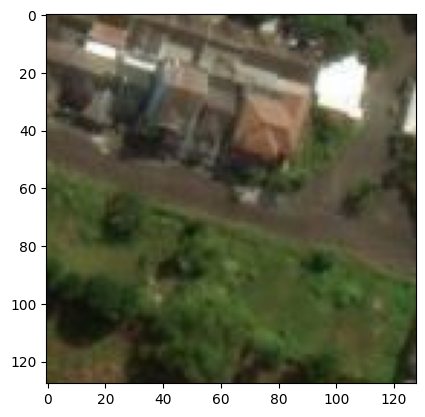

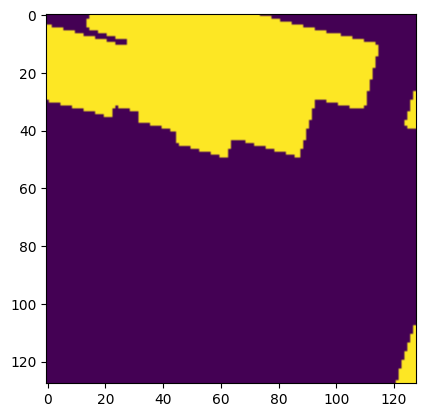

In [ ]:
# Let's plot a sample input RGB image and output image with buildings

plt.imshow(train_xx[200, :, :, :].astype('uint8'))
plt.show()
plt.imshow(train_yy[200, :, :, 0].astype('uint8'))
plt.show()

## **Save to numpy format**

In [ ]:
train_xx.shape

(950, 128, 128, 3)

In [ ]:
np.save('train_xx.npy', train_xx)
np.save('train_yy.npy', train_yy)
np.save("test_xx.npy", test_xx)
np.save("test_yy.npy", test_yy)

In [ ]:
# If you want to save npy
# save_dir = "/content/gdrive/MyDrive/data_atap"  # contoh folder


# import os
# os.makedirs(save_dir, exist_ok=True)

# np.save(os.path.join(save_dir, 'train_xx.npy'), train_xx)
# np.save(os.path.join(save_dir, 'train_yy.npy'), train_yy)
# np.save(os.path.join(save_dir, 'test_xx.npy'), test_xx)
# np.save(os.path.join(save_dir, 'test_yy.npy'), test_yy)


In [ ]:
# If you already have npy
# from google.colab import drive
# drive.mount('/content/gdrive')
# import os
# import numpy as np

# load_dir = "/content/gdrive/MyDrive/data_atap"

# train_xx = np.load(os.path.join(load_dir, 'train_xx.npy'))
# train_yy = np.load(os.path.join(load_dir, 'train_yy.npy'))
# test_xx  = np.load(os.path.join(load_dir, 'test_xx.npy'))
# test_yy  = np.load(os.path.join(load_dir, 'test_yy.npy'))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


#U-Net Model

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    Concatenate, Dropout, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Input
x_in = Input(shape=(128, 128, 3))

# ==== ENCODER ====
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_in)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_skip1 = BatchNormalization()(x_skip1)
x_temp = MaxPooling2D((2, 2))(x_skip1)

x_temp = Conv2D(64, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip2 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_skip2 = BatchNormalization()(x_skip2)
x_temp = MaxPooling2D((2, 2))(x_skip2)

x_temp = Conv2D(128, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)
x_skip3 = Conv2D(128, (3, 3), activation='relu', padding='same')(x_temp)
x_skip3 = BatchNormalization()(x_skip3)
x_temp = MaxPooling2D((2, 2))(x_skip3)

# ==== BOTTLENECK ====
x_temp = Conv2D(256, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.4)(x_temp)
x_temp = Conv2D(256, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = BatchNormalization()(x_temp)

# ==== DECODER ====
x_temp = Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip3])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)

x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip2])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)

x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip1])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)

# ==== OUTPUT ====
x_out = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x_temp)

model = Model(inputs=x_in, outputs=x_out)

# ==== COMPILE ====
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      9,248 │ dropout_14[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     36,928 │ dropout_15[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    147,584 │ dropout_16[0][0]

 Total params: 1,657,409 (6.32 MB)

 Trainable params: 1,654,593 (6.31 MB)

 Non-trainable params: 2,816 (11.00 KB)

#Training

In [ ]:
checkpoint = ModelCheckpoint(
    filepath='/content/gdrive/MyDrive/dataset/model_seg.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Convert test data to float32 before validation
test_xx = test_xx.astype('float32')
test_yy = test_yy.astype('float32')

history = model.fit(
    train_xx, train_yy,
    validation_data=(test_xx, test_yy),
    epochs=100,
    batch_size=16,   
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7286 - loss: 0.5933
Epoch 1: val_loss improved from inf to 0.61448, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 397ms/step - accuracy: 0.7292 - loss: 0.5921 - val_accuracy: 0.7304 - val_loss: 0.6145
Epoch 2/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8110 - loss: 0.4363
Epoch 2: val_loss improved from 0.61448 to 0.51422, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.8112 - loss: 0.4359 - val_accuracy: 0.7502 - val_loss: 0.5142
Epoch 3/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8278 - loss: 0.4003
Epoch 3: val_loss improved from 0.51422 to 0.44760, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8280 - loss: 0.4000 - val_accuracy: 0.8140 - val_loss: 0.4476
Epoch 4/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8466 - loss: 0.3665
Epoch 4: val_loss improved from 0.44760 to 0.41733, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8464 - loss: 0.3668 - val_accuracy: 0.8304 - val_loss: 0.4173
Epoch 5/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8470 - loss: 0.3623
Epoch 5: val_loss did not improve from 0.41733
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8470 - loss: 0.3624 - val_accuracy: 0.6717 - val_loss: 1.3129
Epoch 6/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8507 - loss: 0.3540
Epoch 6: val_loss improved from 0.41733 to 0.35715, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


...

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9604 - loss: 0.1061 - val_accuracy: 0.9564 - val_loss: 0.1268
Epoch 79/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9620 - loss: 0.1022
Epoch 79: val_loss did not improve from 0.12683
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9620 - loss: 0.1023 - val_accuracy: 0.9540 - val_loss: 0.1324
Epoch 80/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9611 - loss: 0.1051
Epoch 80: val_loss did not improve from 0.12683
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9610 - loss: 0.1052 - val_accuracy: 0.9552 - val_loss: 0.1299
Epoch 81/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9611 - loss: 0.1048
Epoch 81: val_loss did not improve from 0.12683
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9611 - loss: 0.1048 - val_accuracy: 0.9564 - val_loss: 0.1293
Epoch 82/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9618 - loss: 0.1026
Epoch 82: val_loss improved from 0.12683 to 

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9618 - loss: 0.1026 - val_accuracy: 0.9578 - val_loss: 0.1256
Epoch 83/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9622 - loss: 0.1019
Epoch 83: val_loss did not improve from 0.12563
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9622 - loss: 0.1019 - val_accuracy: 0.9517 - val_loss: 0.1419
Epoch 84/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9609 - loss: 0.1045
Epoch 84: val_loss improved from 0.12563 to 0.12361, saving model to /content/gdrive/MyDrive/dataset/model_seg.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9609 - loss: 0.1045 - val_accuracy: 0.9582 - val_loss: 0.1236
Epoch 85/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9635 - loss: 0.0983
Epoch 85: val_loss did not improve from 0.12361
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9634 - loss: 0.0984 - val_accuracy: 0.9447 - val_loss: 0.1654
Epoch 86/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9592 - loss: 0.1097
Epoch 86: val_loss did not improve from 0.12361
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9591 - loss: 0.1102 - val_accuracy: 0.8231 - val_loss: 0.5167
Epoch 87/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9496 - loss: 0.1345
Epoch 87: val_loss did not improve from 0.12361
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9497 - loss: 0.1342 - val_accuracy: 0.9432 - val_loss: 0.1653
Epoch 88/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9592 - loss: 0.1103
Epoch 88: val_loss did not improve from 0.12

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9649 - loss: 0.0953 - val_accuracy: 0.9589 - val_loss: 0.1222
Epoch 94/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9637 - loss: 0.0985
Epoch 94: val_loss did not improve from 0.12216
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9637 - loss: 0.0985 - val_accuracy: 0.9594 - val_loss: 0.1246
Epoch 95/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9633 - loss: 0.0994
Epoch 95: val_loss did not improve from 0.12216
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9633 - loss: 0.0994 - val_accuracy: 0.9553 - val_loss: 0.1329
Epoch 96/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9626 - loss: 0.1008
Epoch 96: val_loss did not improve from 0.12216
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9626 - loss: 0.1007 - val_accuracy: 0.9567 - val_loss: 0.1298
Epoch 97/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9639 - loss: 0.0981
Epoch 97: val_loss did not improve from 0.12

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9626 - loss: 0.1011 - val_accuracy: 0.9595 - val_loss: 0.1209
Epoch 99/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9657 - loss: 0.0934
Epoch 99: val_loss did not improve from 0.12088
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9656 - loss: 0.0935 - val_accuracy: 0.9462 - val_loss: 0.1590
Epoch 100/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9651 - loss: 0.0946
Epoch 100: val_loss did not improve from 0.12088
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9651 - loss: 0.0946 - val_accuracy: 0.9586 - val_loss: 0.1267
Restoring model weights from the end of the best epoch: 98.


#Plot Accuracy & Loss

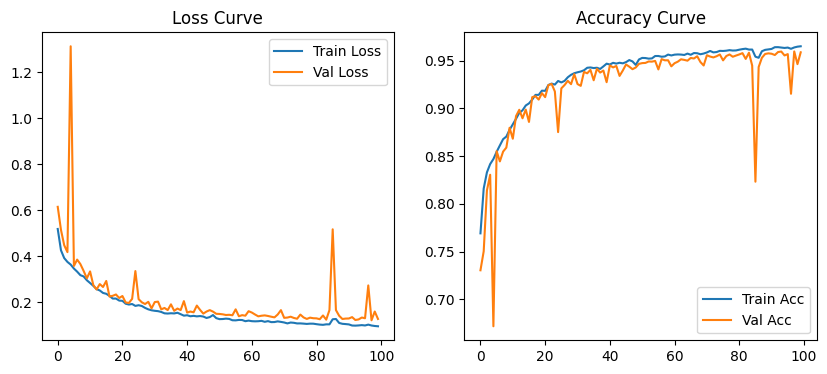

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curve')
plt.show()


# Check Samples Results

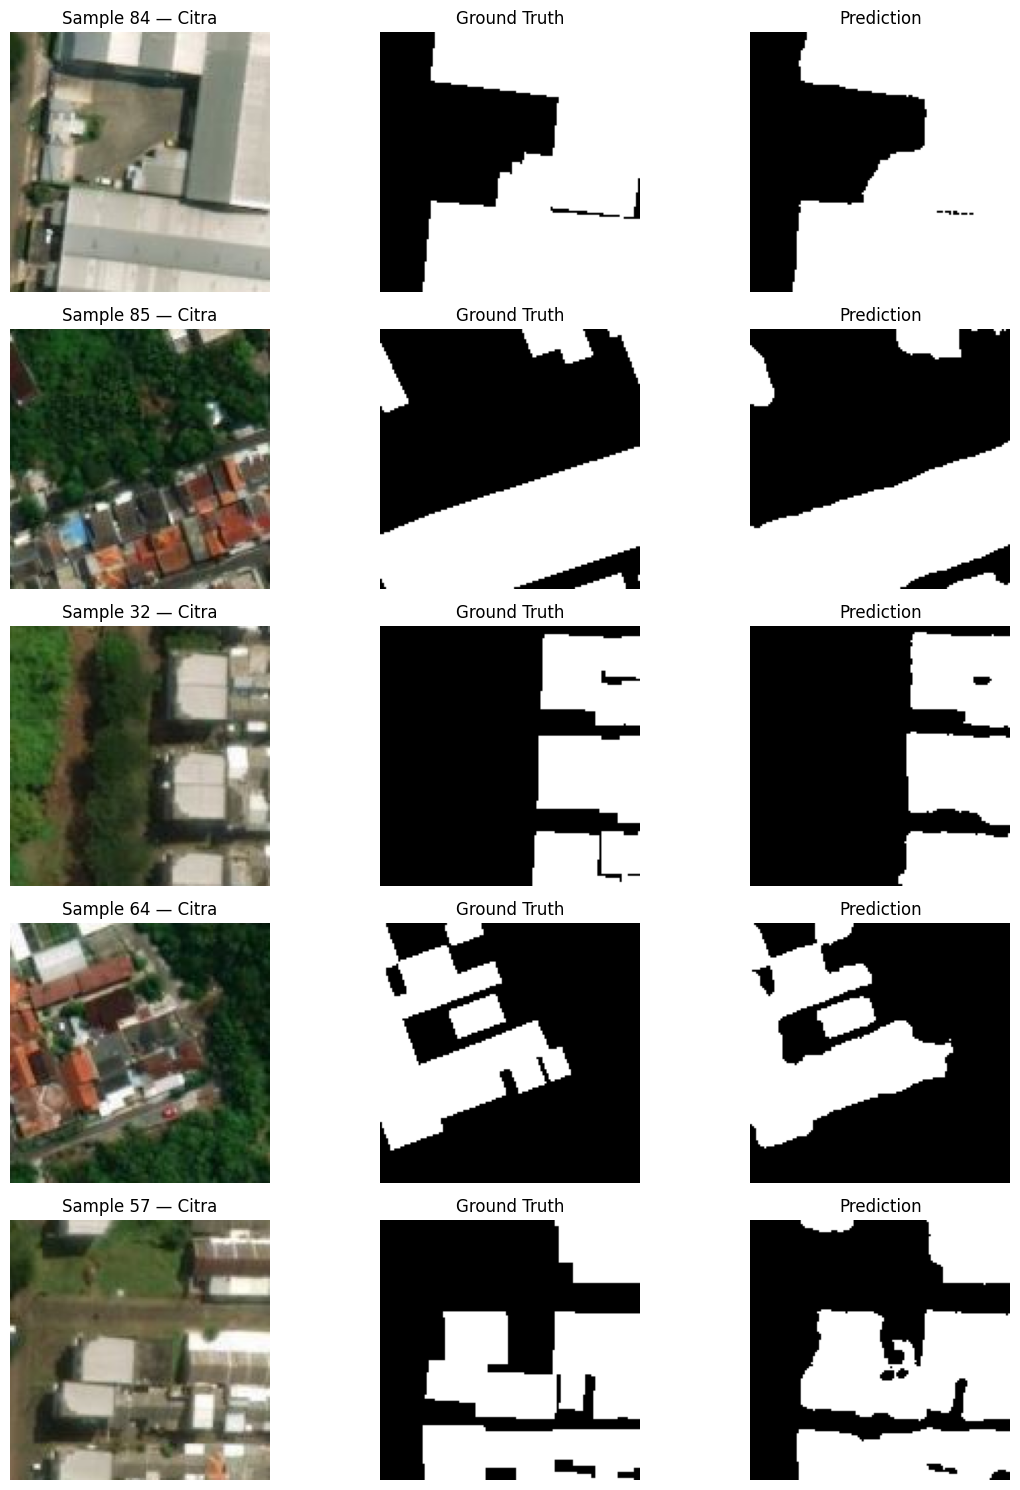

In [ ]:
num_visualize = 5
indices = np.random.choice(len(test_xx), num_visualize, replace=False)

plt.figure(figsize=(12, num_visualize * 3))

for i, idx in enumerate(indices):
    image = test_xx[idx]
    gt = test_yy[idx, :, :, 0]   
    pred = pred_test[idx, :, :, 0]  

    image_disp = (image - np.min(image)) / (np.max(image) - np.min(image))

    plt.subplot(num_visualize, 3, i*3 + 1)
    plt.imshow(image_disp)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(num_visualize, 3, i*3 + 2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_visualize, 3, i*3 + 3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
test_yy = test_yy.astype('uint8')
pred_test = pred_test.astype('uint8')

In [ ]:
def calculate_metrics(ground_truth, predicted_mask):
    # Flatten the binary masks to 1D arrays
    ground_truth = ground_truth.ravel()
    predicted_mask = predicted_mask.ravel()

    # True Positives, False Positives, False Negatives
    TP = np.sum((ground_truth == 1) & (predicted_mask == 1))
    FP = np.sum((ground_truth == 0) & (predicted_mask == 1))
    FN = np.sum((ground_truth == 1) & (predicted_mask == 0))

    # True Negatives (optional, may not be needed for all cases)
    TN = np.sum((ground_truth == 0) & (predicted_mask == 0))

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN)

    return precision, recall, f1_score, iou

In [ ]:
print(calculate_metrics(test_yy, pred_test))

(0.8668725128857868, 0.9033016203847093, 0.8847122221924824, 0.7932591388490682)
